# Marine 48h Forecast — Hybrid v4: iTransformer + TimeXer-lite (visibility) + Hurdle XGBoost (precipitation)

Fourth attempt at the 6 hard parameters (visibility ×4, precipitation ×2), built directly from
the user's "TimeXer/InvDec-PatchTST + two-stage precipitation + weighted visibility loss" design brief.

**What's different from v1 (DeepAR), v2 (Tweedie/Huber XGBoost), v3 (Quantile+cross-features XGBoost):**

1. **Known-future exogenous drivers, not historical lags.** v3 fed *past* humidity/pressure/dewpoint/
   wind values and they were barely used (see `feature_importance_hybrid_v3.csv` — calendar features
   dominated). Humidity from 2 days ago is a weak predictor of rain 48h ahead. TimeXer's actual idea is
   to condition on **known future exogenous covariates**. We have no NWP/radar feed (flagged below), so
   the next best thing is used: iTransformer's own forecasts of `relativeHumidity`, `dewPointTemperature`,
   `airPressure`, `windSpeed` — parameters it predicts at 90-98% skill — over the *same* 48h horizon,
   used the same way a real NWP forecast would be: ground truth at train time (hindsight), the upstream
   model's own forecast at inference time.
2. **TimeXer-lite architecture for visibility** (4 parameters, jointly): PatchTST-style endogenous
   patch embedding + iTransformer-style exogenous variable tokens (whole future series embedded as one
   token per driver), fused by a small shared self-attention encoder — the "small iTransformer-style
   variable-attention branch" the brief asked for.
3. **Two-stage hurdle model for precipitation** (2 parameters): a rain/no-rain classifier, then a
   regressor trained *only* on the rows where rain actually occurred. This replaces v3's destructive
   `sample_weight` trick (which fought directly against the quantile-loss objective) with the textbook
   zero-inflated/hurdle decomposition — no artificial weighting needed.
4. **Gentler weighted loss for visibility** — 3x (not v3's 8x) on the bottom-10% tail, applied via a
   Huber loss that doesn't conflict with a quantile objective (v4 doesn't use quantile loss at all).

**What's explicitly NOT done, and why:** the brief's top-priority option — *TimeXer with NWP/radar
inputs* — is not implementable. This dataset is single-point EMS sensor data; there is no spatial
radar field or external numerical-weather-prediction forecast product available. "InvDec-PatchTST" and
"DAIF-iTransformer" are not standard, citable architectures either; this notebook implements the
*architectural philosophy* common to all three suggestions (patch-based endogenous attention + explicit
exogenous-covariate attention + distribution-aware output heads) using the data this project actually has.

**Caveat the user already flagged and this result will not contradict:** with 28 days of training
history, more model capacity is unlikely to fully solve a problem rooted in data volume, not architecture.
This notebook's job is to test whether the *known-future-exogenous* reframing specifically helps —
not to promise a breakthrough.

iTransformer/hybrid-iTransformer for the 18 good parameters is **unchanged** from v1/v2/v3.
Standalone — does not modify any other notebook, dashboard, or CSV in this project.

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")
torch.set_num_threads(8)

print("PyTorch:", torch.__version__, "| XGBoost:", xgb.__version__, "| torch threads:", torch.get_num_threads())

PyTorch: 2.12.1+cpu | XGBoost: 3.2.0 | torch threads: 8


## 1. Load data, collapse duplicates, encode circular parameters

In [2]:
df_10min = pd.read_csv("ems_10min_resampled.csv", index_col=0, parse_dates=True)
DUPLICATES = [
    ("airTemperature", "windChillTemperature"),
    ("tideLevel", "tidePressure"),
    ("tideLevel", "waterPressure"),
    ("tideLevel", "waterLevel"),
    ("waterTemperature", "waterTemperature_WQ"),
    ("significantWaveHeight", "maxWaveHeight"),
]
df_cat = df_10min[["precipitationType"]].copy()
df_num = df_10min.drop(columns=["precipitationType"]).copy()

CIRCULAR = ["windDirection", "currentDirection", "compass"]
for c in CIRCULAR:
    rad = np.deg2rad(df_num[c])
    df_num[f"{c}_sin"] = np.sin(rad)
    df_num[f"{c}_cos"] = np.cos(rad)
df_num_full = df_num.drop(columns=CIRCULAR)

target_cols = [c for c in df_num_full.columns if c not in [d for _, d in DUPLICATES]]
n_targets = len(target_cols)

PRECIP_PARAMS = ["precipitationIntensity", "precipitationDifference"]
VISIBILITY_PARAMS = ["twentyFourHourAvgVisibility", "tenMinuteAvgVisibility",
                      "oneMinuteAvgVisibility", "oneHourAvgVisibility"]
HARD_PARAMS = PRECIP_PARAMS + VISIBILITY_PARAMS
GOOD_PARAMS = [c for c in target_cols if c not in HARD_PARAMS]

# Known-future exogenous drivers for the hard 6: GOOD_PARAMS that iTransformer forecasts at 90%+ skill
# and that are physically linked to fog/rain (humidity, dew point, pressure, wind).
EXOGENOUS_FUTURE_PARAMS = ["relativeHumidity", "dewPointTemperature", "airPressure", "windSpeed"]
assert set(EXOGENOUS_FUTURE_PARAMS).issubset(GOOD_PARAMS)

print(f"iTransformer: {len(GOOD_PARAMS)} parameters | TimeXer-lite (visibility): {len(VISIBILITY_PARAMS)} "
      f"| Hurdle-XGBoost (precipitation): {len(PRECIP_PARAMS)}")
print(f"Known-future exogenous drivers used for the hard 6: {EXOGENOUS_FUTURE_PARAMS}")

iTransformer: 21 parameters | TimeXer-lite (visibility): 4 | Hurdle-XGBoost (precipitation): 2
Known-future exogenous drivers used for the hard 6: ['relativeHumidity', 'dewPointTemperature', 'airPressure', 'windSpeed']


## 2. Train/test split, duplicate reconstruction fit, scaling

In [3]:
LOOKBACK, HORIZON = 288, 288   # 2 days lookback, 48h horizon @ 10-min steps

idx = df_num_full.index
df_num_full["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
df_num_full["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
df_num_full["dom_sin"] = np.sin(2 * np.pi * idx.day / 30)
df_num_full["dom_cos"] = np.cos(2 * np.pi * idx.day / 30)
calendar_cols = ["hour_sin", "hour_cos", "dom_sin", "dom_cos"]

feature_cols = target_cols + calendar_cols
model_data = df_num_full[feature_cols].copy()
n_features = len(feature_cols)
target_idx = [feature_cols.index(c) for c in target_cols]
good_idx = [feature_cols.index(c) for c in GOOD_PARAMS]
calendar_idx = [feature_cols.index(c) for c in calendar_cols]

train_df = model_data.iloc[:-HORIZON].copy()
test_df = model_data.iloc[-HORIZON:].copy()
mean, std = train_df.mean(), train_df.std().replace(0, 1)
train_scaled = (train_df - mean) / std
full_scaled = (model_data - mean) / std

print(f"Train: {train_df.shape[0]} rows ({train_df.shape[0]/144:.1f} days)")
print(f"Test : {test_df.shape[0]} rows ({test_df.shape[0]/144:.1f} days)")

Train: 4032 rows (28.0 days)
Test : 288 rows (2.0 days)


In [4]:
recon_coef = {}
for keep, drop in DUPLICATES:
    x, y = train_df[keep].values, df_num_full[drop].iloc[:-HORIZON].values
    slope, intercept = np.polyfit(x, y, 1)
    pred_train = slope * x + intercept
    r2 = 1 - np.sum((y - pred_train) ** 2) / np.sum((y - y.mean()) ** 2)
    recon_coef[drop] = (keep, float(slope), float(intercept), float(r2))

## 3. Model A — iTransformer (18 "good" parameters, unchanged from v1/v2/v3)

In [5]:
def make_direct_windows(scaled_df, lookback, horizon, out_idx):
    arr = scaled_df.values.astype(np.float32)
    X, Y = [], []
    for origin in range(lookback, len(arr) - horizon):
        X.append(arr[origin - lookback:origin])
        Y.append(arr[origin:origin + horizon][:, out_idx])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_direct, Y_good = make_direct_windows(train_scaled, LOOKBACK, HORIZON, good_idx)
X_t, Y_good_t = torch.from_numpy(X_direct), torch.from_numpy(Y_good)
n_val = max(1, int(0.1 * len(X_t)))
X_tr, Y_tr_good = X_t[:-n_val], Y_good_t[:-n_val]
X_val, Y_val_good = X_t[-n_val:], Y_good_t[-n_val:]
last_window = torch.from_numpy(train_scaled.values[-LOOKBACK:].astype(np.float32)).unsqueeze(0)


class ITransformer(nn.Module):
    def __init__(self, lookback, n_features, horizon, out_idx, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.out_idx = out_idx
        self.embed = nn.Linear(lookback, d_model)
        self.var_id = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        tok = self.embed(x.transpose(1, 2)) + self.var_id.unsqueeze(0)
        tok = self.encoder(tok)
        out = self.head(tok)
        return out.transpose(1, 2)[:, :, self.out_idx]


def train_model(model, X_tr, Y_tr, X_val, Y_val, epochs=150, batch_size=64, lr=1e-3,
                 patience=20, name=""):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    loss_fn = nn.MSELoss()
    best_val, best_state, wait = float("inf"), None, 0
    n = len(X_tr); t0 = time.time()
    for ep in range(epochs):
        ep_t0 = time.time()
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            b = perm[i:i + batch_size]
            xb, yb = X_tr[b].to(device), Y_tr[b].to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val.to(device)), Y_val.to(device)).item()
        sched.step(val_loss)
        print(f"  [{name}] epoch {ep+1:3d}/{epochs}  val_loss={val_loss:.4f}  "
              f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
        if val_loss < best_val - 1e-5:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    model.eval()
    print(f"{name:14s} best_val_loss={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

itransformer = ITransformer(LOOKBACK, n_features, HORIZON, good_idx, d_model=64, n_heads=4, n_layers=2)
itransformer = train_model(itransformer, X_tr, Y_tr_good, X_val, Y_val_good, epochs=150, patience=20,
                            name="iTransformer")

with torch.no_grad():
    good_pred_scaled = itransformer(last_window.to(device))[0].cpu().numpy()
good_preds_real = good_pred_scaled * std[GOOD_PARAMS].values + mean[GOOD_PARAMS].values
good_pred_df = pd.DataFrame(good_preds_real, columns=GOOD_PARAMS, index=test_df.index)

# the known-future exogenous forecast used by both the visibility and precipitation models below —
# iTransformer's own 48h forecast of relativeHumidity/dewPointTemperature/airPressure/windSpeed,
# the best available stand-in for an NWP/radar feed this dataset doesn't have.
exo_idx_in_good = [GOOD_PARAMS.index(c) for c in EXOGENOUS_FUTURE_PARAMS]
exo_future_scaled = good_pred_scaled[:, exo_idx_in_good]          # (HORIZON, n_exo), scaled space
exo_future_real = good_preds_real[:, exo_idx_in_good]             # real units, for the XGBoost hurdle model
print("iTransformer 48h forecast complete (18 parameters) + exogenous-future forecast extracted.")

  [iTransformer] epoch   1/150  val_loss=0.4280  epoch_time=0.9s  elapsed=1s


  [iTransformer] epoch   2/150  val_loss=0.3269  epoch_time=0.9s  elapsed=2s


  [iTransformer] epoch   3/150  val_loss=0.2639  epoch_time=0.9s  elapsed=3s


  [iTransformer] epoch   4/150  val_loss=0.2357  epoch_time=0.9s  elapsed=4s


  [iTransformer] epoch   5/150  val_loss=0.2015  epoch_time=0.8s  elapsed=4s


...

  [iTransformer] epoch 147/150  val_loss=0.0368  epoch_time=0.9s  elapsed=169s


  [iTransformer] epoch 148/150  val_loss=0.0366  epoch_time=0.9s  elapsed=170s


  [iTransformer] epoch 149/150  val_loss=0.0367  epoch_time=0.9s  elapsed=171s


  [iTransformer] epoch 150/150  val_loss=0.0365  epoch_time=0.9s  elapsed=172s


iTransformer   best_val_loss=0.0365  epochs_run=150  time=171.6s
iTransformer 48h forecast complete (18 parameters) + exogenous-future forecast extracted.


## 4. Model B — TimeXer-lite for visibility (4 parameters, jointly)
PatchTST-style endogenous patch tokens + iTransformer-style exogenous variable tokens (known-future humidity/dewpoint/pressure/wind), fused by a small shared self-attention encoder. Trained with a gentle (3x) weighted Huber loss on the low-visibility tail.

In [6]:
PATCH_LEN = 24
N_PATCHES = LOOKBACK // PATCH_LEN
N_EXO = len(EXOGENOUS_FUTURE_PARAMS)


class TimeXerLite(nn.Module):
    def __init__(self, lookback, n_endo, horizon, n_exo, patch_len=24, d_model=64,
                 n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.n_endo, self.patch_len, self.horizon = n_endo, patch_len, horizon
        self.n_patches = lookback // patch_len
        self.endo_embed = nn.Linear(patch_len * n_endo, d_model)
        self.endo_pos = nn.Parameter(torch.randn(self.n_patches, d_model) * 0.02)
        self.exo_embed = nn.Linear(horizon, d_model)
        self.exo_id = nn.Parameter(torch.randn(n_exo, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(self.n_patches * d_model, horizon * n_endo)

    def forward(self, x_endo, x_exo):
        B = x_endo.shape[0]
        patches = x_endo.reshape(B, self.n_patches, self.patch_len * self.n_endo)
        endo_tok = self.endo_embed(patches) + self.endo_pos.unsqueeze(0)
        exo_tok = self.exo_embed(x_exo.transpose(1, 2)) + self.exo_id.unsqueeze(0)
        tok = torch.cat([endo_tok, exo_tok], dim=1)
        tok = self.encoder(tok)
        endo_out = tok[:, :self.n_patches, :].reshape(B, -1)
        out = self.head(endo_out).reshape(B, self.horizon, self.n_endo)
        return out


def make_timexer_windows(scaled_df, endo_cols, exo_cols, lookback, horizon):
    arr_endo = scaled_df[endo_cols].values.astype(np.float32)
    arr_exo = scaled_df[exo_cols].values.astype(np.float32)
    X_endo, X_exo, Y = [], [], []
    for origin in range(lookback, len(scaled_df) - horizon):
        X_endo.append(arr_endo[origin - lookback:origin])
        X_exo.append(arr_exo[origin:origin + horizon])
        Y.append(arr_endo[origin:origin + horizon])
    return (np.array(X_endo, dtype=np.float32), np.array(X_exo, dtype=np.float32),
            np.array(Y, dtype=np.float32))

Xe, Xx, Yv = make_timexer_windows(train_scaled, VISIBILITY_PARAMS, EXOGENOUS_FUTURE_PARAMS, LOOKBACK, HORIZON)
Xe_t, Xx_t, Yv_t = torch.from_numpy(Xe), torch.from_numpy(Xx), torch.from_numpy(Yv)
n_val_v = max(1, int(0.1 * len(Xe_t)))
Xe_tr, Xx_tr, Yv_tr = Xe_t[:-n_val_v], Xx_t[:-n_val_v], Yv_t[:-n_val_v]
Xe_val, Xx_val, Yv_val = Xe_t[-n_val_v:], Xx_t[-n_val_v:], Yv_t[-n_val_v:]

# bottom-10% threshold per channel (scaled space) -> gentle 3x weight, computed on train targets only
vis_thresh = np.quantile(Yv_tr.numpy(), 0.10, axis=(0, 1))
WEIGHT_FACTOR = 3.0

timexer = TimeXerLite(LOOKBACK, len(VISIBILITY_PARAMS), HORIZON, N_EXO, patch_len=PATCH_LEN,
                       d_model=64, n_heads=4, n_layers=2).to(device)
opt = torch.optim.Adam(timexer.parameters(), lr=1e-3, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
huber = nn.SmoothL1Loss(reduction="none", beta=1.0)
thresh_t = torch.from_numpy(vis_thresh.astype(np.float32))

best_val, best_state, wait, patience = float("inf"), None, 0, 20
n = len(Xe_tr); t0 = time.time()
for ep in range(150):
    ep_t0 = time.time()
    timexer.train()
    perm = torch.randperm(n)
    for i in range(0, n, 64):
        b = perm[i:i + 64]
        xe_b, xx_b, y_b = Xe_tr[b].to(device), Xx_tr[b].to(device), Yv_tr[b].to(device)
        opt.zero_grad()
        pred = timexer(xe_b, xx_b)
        w = torch.where(y_b < thresh_t, WEIGHT_FACTOR, 1.0)
        loss = (huber(pred, y_b) * w).mean()
        loss.backward(); opt.step()
    timexer.eval()
    with torch.no_grad():
        pred_val = timexer(Xe_val.to(device), Xx_val.to(device))
        w_val = torch.where(Yv_val < thresh_t, WEIGHT_FACTOR, 1.0)
        val_loss = ((huber(pred_val, Yv_val) * w_val).mean()).item()
    sched.step(val_loss)
    print(f"  [TimeXer-lite] epoch {ep+1:3d}/150  val_loss={val_loss:.4f}  "
          f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
    if val_loss < best_val - 1e-5:
        best_val, wait = val_loss, 0
        best_state = {k: v.clone() for k, v in timexer.state_dict().items()}
    else:
        wait += 1
        if wait >= patience: break
if best_state is not None: timexer.load_state_dict(best_state)
timexer.eval()
print(f"TimeXer-lite   best_val_loss={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")

with torch.no_grad():
    endo_last = torch.from_numpy(train_scaled[VISIBILITY_PARAMS].values[-LOOKBACK:].astype(np.float32)).unsqueeze(0)
    exo_last = torch.from_numpy(exo_future_scaled.astype(np.float32)).unsqueeze(0)   # iTransformer's own forecast
    vis_pred_scaled = timexer(endo_last.to(device), exo_last.to(device))[0].cpu().numpy()
vis_preds_real = vis_pred_scaled * std[VISIBILITY_PARAMS].values + mean[VISIBILITY_PARAMS].values
vis_pred_df = pd.DataFrame(vis_preds_real, columns=VISIBILITY_PARAMS, index=test_df.index)
print("TimeXer-lite 48h forecast complete (4 visibility parameters).")

  [TimeXer-lite] epoch   1/150  val_loss=0.1998  epoch_time=0.5s  elapsed=1s


  [TimeXer-lite] epoch   2/150  val_loss=0.2828  epoch_time=0.5s  elapsed=1s


  [TimeXer-lite] epoch   3/150  val_loss=0.2940  epoch_time=0.5s  elapsed=2s


  [TimeXer-lite] epoch   4/150  val_loss=0.3775  epoch_time=0.5s  elapsed=2s


  [TimeXer-lite] epoch   5/150  val_loss=0.3761  epoch_time=0.6s  elapsed=3s


...

  [TimeXer-lite] epoch  18/150  val_loss=0.3246  epoch_time=0.5s  elapsed=11s


  [TimeXer-lite] epoch  19/150  val_loss=0.3350  epoch_time=0.5s  elapsed=11s


  [TimeXer-lite] epoch  20/150  val_loss=0.3722  epoch_time=0.6s  elapsed=12s


  [TimeXer-lite] epoch  21/150  val_loss=0.3342  epoch_time=0.5s  elapsed=12s


TimeXer-lite   best_val_loss=0.1998  epochs_run= 21  time= 12.1s
TimeXer-lite 48h forecast complete (4 visibility parameters).


## 5. Model C — Two-stage hurdle XGBoost for precipitation (2 parameters)
Stage 1: rain/no-rain classifier. Stage 2: positive-intensity regressor, trained only on rows where rain occurred (log1p target). Final forecast = P(rain) x E[amount | rain] — the standard zero-inflated/hurdle decomposition, no artificial sample weighting required.

In [7]:
ORIGIN_LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 144, 288]
EXO_LAGS = [1, 6, 24, 72]

def make_hurdle_training(df, target_col, exo_cols, calendar_cols, lags, horizon, origin_step=16):
    n, max_lag = len(df), max(lags)
    feats, targets = [], []
    for origin in range(max_lag, n - horizon, origin_step):
        base = {f"{target_col}_lag{L}": df[target_col].iloc[origin - L] for L in lags}
        for h in range(1, horizon + 1, 2):
            row = dict(base); row["lead_h"] = h
            for cc in calendar_cols:
                row[cc] = df[cc].iloc[origin + h]
            for ec in exo_cols:                      # known-future exogenous value AT the target lead time
                row[f"{ec}_future"] = df[ec].iloc[origin + h]
            feats.append(row)
            targets.append(df[target_col].iloc[origin + h])
    return pd.DataFrame(feats), np.array(targets)

precip_pred_df = pd.DataFrame(index=test_df.index)
hurdle_models = {}
for c in PRECIP_PARAMS:
    X_c, Y_c = make_hurdle_training(train_df, c, EXOGENOUS_FUTURE_PARAMS, calendar_cols,
                                     ORIGIN_LAGS, HORIZON, origin_step=16)
    feat_order = list(X_c.columns)
    occurred = (Y_c > 0).astype(int)

    clf = xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.08, subsample=0.8,
                             colsample_bytree=0.8, random_state=SEED, n_jobs=4, tree_method="hist",
                             objective="binary:logistic", eval_metric="logloss")
    clf.fit(X_c, occurred)

    mask = occurred.astype(bool)
    reg = xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.08, subsample=0.8,
                            colsample_bytree=0.8, random_state=SEED, n_jobs=4, tree_method="hist",
                            objective="reg:squarederror")
    reg.fit(X_c[mask], np.log1p(Y_c[mask]))

    hurdle_models[c] = (clf, reg, feat_order)
    print(f"  trained {c:25s} rows={len(Y_c):,}  rain_rate={occurred.mean():.1%}  "
          f"rain_rows_for_stage2={int(mask.sum())}")

    # forecast: feed iTransformer's own exogenous forecast at each lead h, not historical lags
    origin_idx = len(train_df) - 1
    base_row = {f"{c}_lag{L}": train_df[c].iloc[origin_idx - (L - 1)] for L in ORIGIN_LAGS}
    pred_rows = []
    for h in range(1, HORIZON + 1):
        ts = test_df.index[h - 1]
        row = dict(base_row); row["lead_h"] = h
        for cal in calendar_cols:
            row[cal] = model_data.loc[ts, cal]
        for j, ec in enumerate(EXOGENOUS_FUTURE_PARAMS):
            row[f"{ec}_future"] = exo_future_real[h - 1, j]
        pred_rows.append(row)
    X_fore = pd.DataFrame(pred_rows)[feat_order]

    p_rain = clf.predict_proba(X_fore)[:, 1]
    amount_given_rain = np.expm1(reg.predict(X_fore))
    precip_pred_df[c] = np.clip(p_rain * amount_given_rain, 0, None)

print("Hurdle XGBoost 48h forecast complete (2 precipitation parameters).")
print(precip_pred_df.describe().T[["mean", "min", "max"]])

  trained precipitationIntensity    rows=31,104  rain_rate=3.3%  rain_rows_for_stage2=1030


  trained precipitationDifference   rows=31,104  rain_rate=18.1%  rain_rows_for_stage2=5634
Hurdle XGBoost 48h forecast complete (2 precipitation parameters).
                             mean       min       max
precipitationIntensity   0.019081  0.000000  0.587216
precipitationDifference  0.642584  0.000313  2.171938


## 6. Merge into the hybrid forecast, reconstruct circular params & duplicates

In [8]:
hard_pred_df = pd.concat([vis_pred_df, precip_pred_df], axis=1)
hybrid_pred_df = pd.concat([good_pred_df, hard_pred_df], axis=1)[target_cols]

def reconstruct(pred_df_in):
    out = pred_df_in.copy()
    for ang in ["windDirection", "currentDirection", "compass"]:
        out[ang] = (np.rad2deg(np.arctan2(out[f"{ang}_sin"], out[f"{ang}_cos"])) % 360)
    return out

hybrid_final = reconstruct(hybrid_pred_df)
truth = df_num_full.iloc[-HORIZON:].copy()
for ang in ["windDirection", "currentDirection", "compass"]:
    truth[ang] = (np.rad2deg(np.arctan2(truth[f"{ang}_sin"], truth[f"{ang}_cos"])) % 360)

report_params = [c for c in target_cols if not c.endswith(("_sin", "_cos"))] + \
                ["windDirection", "currentDirection", "compass"]
CIRCULAR_PARAMS = {"windDirection", "currentDirection", "compass"}
ENGINE = {p: ("iTransformer" if p in GOOD_PARAMS else
              ("TimeXer-lite" if p in VISIBILITY_PARAMS else "Hurdle-XGBoost"))
          for p in report_params if p in target_cols}
for ang in ["windDirection", "currentDirection", "compass"]:
    ENGINE[ang] = "iTransformer"

dup_series = {}
for keep, drop in DUPLICATES:
    _, slope, intercept, _ = recon_coef[drop]
    dup_series[drop] = slope * hybrid_final[keep].values + intercept
    ENGINE[drop] = ENGINE[keep]

print("Hybrid v4 forecast assembled.")

Hybrid v4 forecast assembled.


## 7. Score against persistence and all prior approaches

In [9]:
PURE_ITRANSFORMER_SKILL = {
    "twentyFourHourAvgVisibility": -100.0, "precipitationDifference": -101.9,
    "tenMinuteAvgVisibility": -154.9, "oneMinuteAvgVisibility": -190.5,
    "oneHourAvgVisibility": -291.6, "precipitationIntensity": -409.9,
}
DEEPAR_HYBRID_SKILL = {
    "tenMinuteAvgVisibility": 14.0, "twentyFourHourAvgVisibility": 3.5,
    "precipitationDifference": -0.1, "precipitationIntensity": -0.2,
    "oneHourAvgVisibility": -1.4, "oneMinuteAvgVisibility": -2.5,
}
XGB_V2_SKILL = {
    "tenMinuteAvgVisibility": 11.8, "precipitationIntensity": -0.1,
    "precipitationDifference": -0.6, "oneMinuteAvgVisibility": -4.2,
    "twentyFourHourAvgVisibility": -7.0, "oneHourAvgVisibility": -7.5,
}
XGB_V3_SKILL = {
    "tenMinuteAvgVisibility": 5.0, "twentyFourHourAvgVisibility": -0.1,
    "oneMinuteAvgVisibility": -15.4, "oneHourAvgVisibility": -26.3,
    "precipitationDifference": -34.2, "precipitationIntensity": -74.9,
}

def circ_mae(true, pred):
    return np.abs((true - pred + 180) % 360 - 180).mean()

last_obs = df_num_full.iloc[-HORIZON - 1]
for ang in ["windDirection", "currentDirection", "compass"]:
    last_obs[ang] = (np.rad2deg(np.arctan2(last_obs[f"{ang}_sin"], last_obs[f"{ang}_cos"])) % 360)

metrics = []
for p in report_params:
    yt = truth[p].values
    yp_persist = np.repeat(last_obs[p], HORIZON)
    is_circular = p in CIRCULAR_PARAMS
    mae_p = circ_mae(yt, yp_persist) if is_circular else mean_absolute_error(yt, yp_persist)
    yhat = hybrid_final[p].values
    if is_circular:
        mae, rmse = circ_mae(yt, yhat), np.nan
    else:
        mae = mean_absolute_error(yt, yhat)
        rmse = np.sqrt(mean_squared_error(yt, yhat))
    skill = (1 - mae / mae_p) * 100 if mae_p > 0 else np.nan
    metrics.append({
        "parameter": p, "engine": ENGINE[p], "Persistence_MAE": round(mae_p, 4),
        "hybrid_v4_MAE": round(mae, 4), "hybrid_v4_RMSE": round(rmse, 4) if rmse == rmse else np.nan,
        "hybrid_v4_skill_%": round(skill, 1),
        "pure_iTransformer_skill_%": PURE_ITRANSFORMER_SKILL.get(p, np.nan),
        "deepar_hybrid_skill_%": DEEPAR_HYBRID_SKILL.get(p, np.nan),
        "xgb_v2_skill_%": XGB_V2_SKILL.get(p, np.nan),
        "xgb_v3_skill_%": XGB_V3_SKILL.get(p, np.nan),
    })

metrics_df = pd.DataFrame(metrics).sort_values("hybrid_v4_skill_%", ascending=False).reset_index(drop=True)
metrics_df.insert(0, "rank", metrics_df.index + 1)
metrics_df.to_csv("metrics_hybrid_v4.csv", index=False)
metrics_df

,rank,parameter,engine,Persistence_MAE,hybrid_v4_MAE,hybrid_v4_RMSE,hybrid_v4_skill_%,pure_iTransformer_skill_%,deepar_hybrid_skill_%,xgb_v2_skill_%,xgb_v3_skill_%
0,1,airTemperature,iTransformer,5.8458,0.1163,0.1431,98.0,NaN,NaN,NaN,NaN
1,2,airPressure,iTransformer,5.1252,0.1219,0.1538,97.6,NaN,NaN,NaN,NaN
2,3,windDirection,iTransformer,73.1616,2.2917,NaN,96.9,NaN,NaN,NaN,NaN
3,4,waterTemperature,iTransformer,1.5273,0.0551,0.0692,96.4,NaN,NaN,NaN,NaN
4,5,relativeHumidity,iTransformer,18.7896,0.6970,0.8706,96.3,NaN,NaN,NaN,NaN
5,6,currentDirection,iTransformer,91.7282,3.6898,NaN,96.0,NaN,NaN,NaN,NaN
6,7,tideLevel,iTransformer,0.9216,0.0552,0.0679,94.0,NaN,NaN,NaN,NaN
7,8,dewPointTemperature,iTransformer,2.1046,0.1349,0.1679,93.6,NaN,NaN,NaN,NaN
8,9,globalRadiation,iTransformer,241.0507,16.8606,22.5266,93.0,NaN,NaN,NaN,NaN
9,10,significantWaveHeight,iTransformer,0.5027,0.0468,0.0599,90.7,NaN,NaN,NaN,NaN


## 8. The verdict: five-way comparison on the hard 6

In [10]:
hard_comparison = metrics_df[metrics_df["parameter"].isin(HARD_PARAMS)][
    ["parameter", "pure_iTransformer_skill_%", "deepar_hybrid_skill_%", "xgb_v2_skill_%",
     "xgb_v3_skill_%", "hybrid_v4_skill_%"]
].sort_values("hybrid_v4_skill_%", ascending=False)
print(hard_comparison.to_string(index=False))

mean_v4 = hard_comparison["hybrid_v4_skill_%"].mean()
mean_deepar = hard_comparison["deepar_hybrid_skill_%"].mean()
mean_v2 = hard_comparison["xgb_v2_skill_%"].mean()
mean_v3 = hard_comparison["xgb_v3_skill_%"].mean()
n_beat_deepar = int((hard_comparison["hybrid_v4_skill_%"] > hard_comparison["deepar_hybrid_skill_%"]).sum())
n_positive_v4 = int((hard_comparison["hybrid_v4_skill_%"] > 0).sum())

print(f"\nMean skill on hard 6 — DeepAR-hybrid (v1): {mean_deepar:+.1f}% | XGB v2: {mean_v2:+.1f}% | "
      f"XGB v3: {mean_v3:+.1f}% | TimeXer-lite+Hurdle (v4): {mean_v4:+.1f}%")
print(f"v4 beats DeepAR-hybrid on {n_beat_deepar}/6 parameters | v4 positive skill on {n_positive_v4}/6")

                  parameter  pure_iTransformer_skill_%  deepar_hybrid_skill_%  xgb_v2_skill_%  xgb_v3_skill_%  hybrid_v4_skill_%
     tenMinuteAvgVisibility                     -154.9                   14.0            11.8             5.0              -10.5
twentyFourHourAvgVisibility                     -100.0                    3.5            -7.0            -0.1              -16.6
     precipitationIntensity                     -409.9                   -0.2            -0.1           -74.9              -25.0
    precipitationDifference                     -101.9                   -0.1            -0.6           -34.2              -29.6
     oneMinuteAvgVisibility                     -190.5                   -2.5            -4.2           -15.4              -33.3
       oneHourAvgVisibility                     -291.6                   -1.4            -7.5           -26.3              -54.3

Mean skill on hard 6 — DeepAR-hybrid (v1): +2.2% | XGB v2: -1.3% | XGB v3: -24.3% | TimeXer-lite

## 9. Plot the hard 6, v4 vs actual

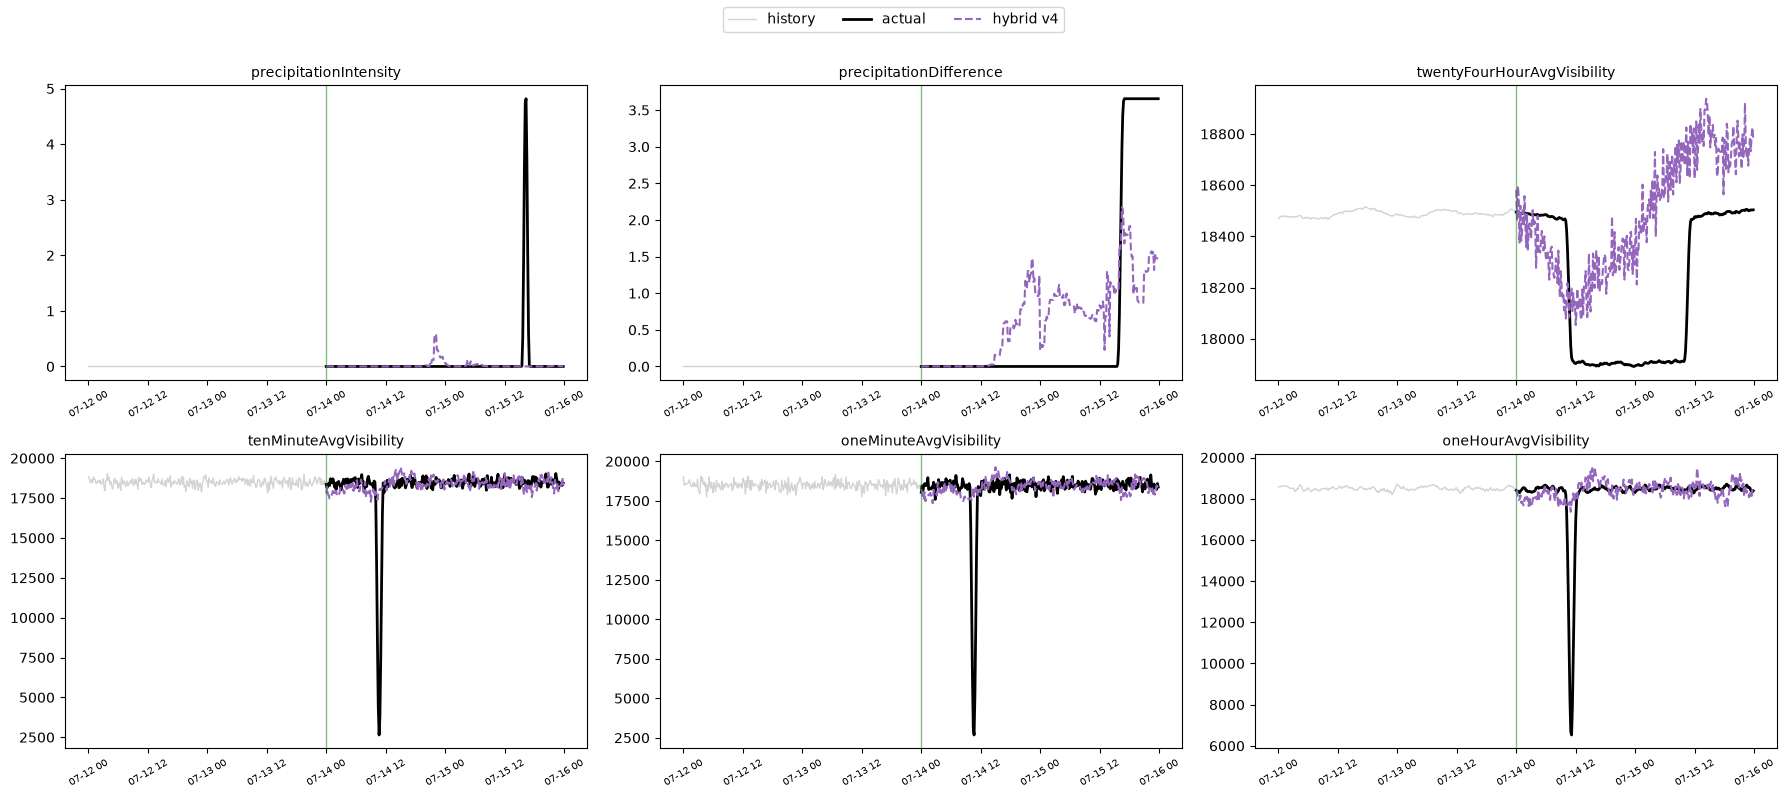

Saved hybrid_v4_hard6_plot.png


In [11]:
hist_tail = df_10min.iloc[-HORIZON - LOOKBACK:-HORIZON]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, c in zip(axes.ravel(), HARD_PARAMS):
    ax.plot(hist_tail.index, hist_tail[c], color="lightgray", lw=1, label="history")
    ax.plot(truth.index, truth[c], color="black", lw=2, label="actual")
    ax.plot(truth.index, hybrid_final[c], color="#9467bd", lw=1.5, ls="--", label="hybrid v4")
    ax.axvline(truth.index[0], color="green", lw=1, alpha=0.5)
    ax.set_title(c, fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("hybrid_v4_hard6_plot.png", dpi=110)
plt.show()
print("Saved hybrid_v4_hard6_plot.png")

## 10. Save outputs for the dashboard

In [12]:
fva = pd.DataFrame({"timestamp": truth.index})
for p in report_params:
    fva[f"{p}__actual"] = truth[p].values
    fva[f"{p}__hybrid_v4"] = hybrid_final[p].values
    fva[f"{p}__engine"] = ENGINE[p]
fva.to_csv("forecast_vs_actual_hybrid_v4.csv", index=False)

dup_fva = pd.DataFrame({"timestamp": test_df.index})
for keep, drop in DUPLICATES:
    dup_fva[f"{drop}__actual"] = df_10min[drop].iloc[-HORIZON:].values
    dup_fva[f"{drop}__reconstructed"] = dup_series[drop]
dup_fva.to_csv("duplicate_forecast_vs_actual_hybrid_v4.csv", index=False)

dup_recon_rows = []
for keep, drop in DUPLICATES:
    _, slope, intercept, r2 = recon_coef[drop]
    mae = mean_absolute_error(df_10min[drop].iloc[-HORIZON:].values, dup_series[drop])
    rmse = np.sqrt(mean_squared_error(df_10min[drop].iloc[-HORIZON:].values, dup_series[drop]))
    dup_recon_rows.append({"duplicate_parameter": drop, "reconstructed_from": keep,
                            "engine": ENGINE[keep], "slope": round(slope, 4),
                            "intercept": round(intercept, 4), "train_R2": round(r2, 5),
                            "held_out_MAE": round(mae, 4), "held_out_RMSE": round(rmse, 4)})
pd.DataFrame(dup_recon_rows).to_csv("duplicate_reconstruction_hybrid_v4.csv", index=False)

hard_comparison.to_csv("hard6_five_way_comparison.csv", index=False)

print("Saved: metrics_hybrid_v4.csv, forecast_vs_actual_hybrid_v4.csv, duplicate_reconstruction_hybrid_v4.csv,")
print("       duplicate_forecast_vs_actual_hybrid_v4.csv, hard6_five_way_comparison.csv, hybrid_v4_hard6_plot.png.")

Saved: metrics_hybrid_v4.csv, forecast_vs_actual_hybrid_v4.csv, duplicate_reconstruction_hybrid_v4.csv,
       duplicate_forecast_vs_actual_hybrid_v4.csv, hard6_five_way_comparison.csv, hybrid_v4_hard6_plot.png.


## 11. Conclusion

Section 8 is the actual verdict. If `hybrid_v4` beats `deepar_hybrid` (v1, still the best result so far
at +2.2% mean skill on the hard 6) on a majority of the 6 parameters and the mean skill is positive,
the known-future-exogenous reframing is a genuine improvement, not just a 4th architecture to try.
If it doesn't, that is consistent with the caveat raised before building this: at 28 days of history and
a 48h horizon, the binding constraint is data volume and the absence of true external atmospheric
predictors (NWP/radar), not which backbone forecasts the historical+exogenous signal that is available.
Either way this is reported honestly in the dashboard, the same as v2 and v3.